In [286]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}\ndevice: {device}")

PyTorch version: 2.7.1
torchvision version: 0.22.1
device: cpu


In [287]:
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

len(train_data.data), len(test_data.data)

(60000, 10000)

Text(0.5, 1.0, '5 - five')

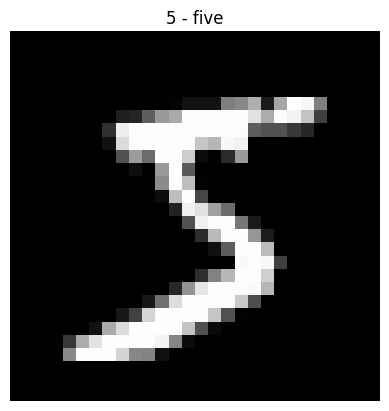

In [288]:
# Viewing a specific image
image, label = train_data[0]
plt.imshow(image.permute(1,2,0), cmap='grey')
plt.axis(False);
plt.title(train_data.classes[label])

In [289]:
from torch.utils.data import DataLoader
batch_size = 32

train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle = False)

print(f"Train dataloader: {len(train_dataloader)} batches of size {batch_size}")
print(f"Test dataloader: {len(test_dataloader)} batches of size {batch_size}")

Train dataloader: 1875 batches of size 32
Test dataloader: 313 batches of size 32


In [290]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [291]:
class conv_autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 1x28x28 -> 1x14x14 -> 1x7x7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=5, stride=3, padding=2),
            nn.ReLU(),
            nn.Conv2d(4, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder: 1x7x7 -> 1x14x14 -> 1x28x28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 4, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(4, 1, kernel_size=5, stride=3, padding=2, output_padding=0),
            nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [292]:
ae_model = conv_autoencoder()

In [293]:
optimizer = torch.optim.SGD(params=ae_model.parameters(), lr=0.1)
loss_fn = nn.MSELoss()
def accuracy_fn(pred, true):
    # can make this later
    pass

In [294]:
def train_step(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device: torch.device = device):
    global train_loss
    train_loss = 0
    model.to(device)
    model.train()
    size = len(data_loader)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        X_pred = model(X)
        loss = loss_fn(X, X_pred)
        train_loss += loss/size
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Train loss: {train_loss:.5f}")

In [ ]:
train_time_start_on_gpu = timer()
epochs = 10
train_losses = []

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch+1}\n-----------")
    
    train_step(data_loader=train_dataloader, model=ae_model, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)
    train_losses.append(train_loss.item())
train_time_end_on_gpu = timer()
total_train_time = print_train_time(start=train_time_start_on_gpu, end=train_time_end_on_gpu, device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1
-----------


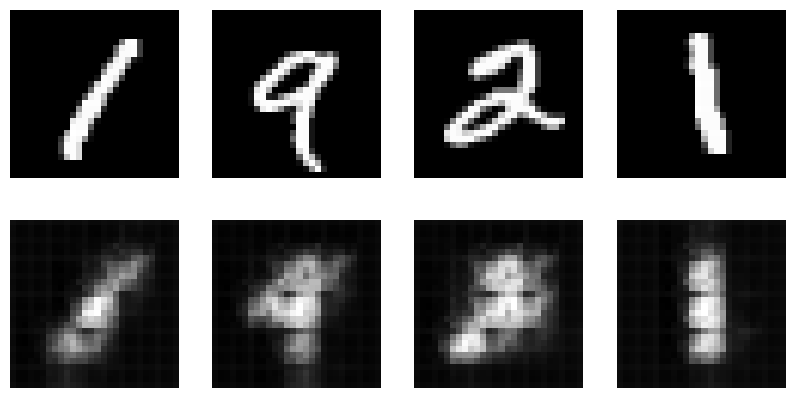

In [ ]:
fig, axs = plt.subplots(2, 4, figsize=(10,5))
item_start_index = 3
#fig.axis(False)
#plt.axis(False);
for i in range(4):
    image, label = ae_model(train_data[item_start_index+i][0]).detach(), train_data[item_start_index +i][1]
    axs[1,i].imshow(image.permute(1,2,0), cmap='grey')
    axs[1,i].axis('off')
for i in range(4):
    image, label = train_data[item_start_index+i]
    axs[0,i].imshow(image.permute(1,2,0), cmap='grey')
    axs[0,i].axis('off')